In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("../data/processed/cleaned_retail.csv")

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Month,DayOfWeek,Hour,IsWeekend
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,December,Tuesday,7,0
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,December,Tuesday,7,0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,December,Tuesday,7,0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,December,Tuesday,7,0
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,December,Tuesday,7,0


In [3]:
inventory = df.groupby("Description").agg({

    "Quantity":"sum",

    "Revenue":"sum",

    "Invoice":"nunique"

})

inventory.columns=[

    "TotalQuantity",

    "TotalRevenue",

    "TotalOrders"

]

inventory.head()

,TotalQuantity,TotalRevenue,TotalOrders
Description,,,
DOORMAT UNION JACK GUNS AND ROSES,169,1084.75,51
3 STRIPEY MICE FELTCRAFT,663,1243.05,112
4 PURPLE FLOCK DINNER CANDLES,340,535.96,51
50'S CHRISTMAS GIFT BAG LARGE,1885,2272.25,109
ANIMAL STICKERS,385,80.85,12


In [4]:
months = df["InvoiceDate"].dt.to_period("M").nunique()

inventory["AvgMonthlyDemand"] = (

    inventory["TotalQuantity"] / months

)

inventory.head()

,TotalQuantity,TotalRevenue,TotalOrders,AvgMonthlyDemand
Description,,,,
DOORMAT UNION JACK GUNS AND ROSES,169,1084.75,51,6.76
3 STRIPEY MICE FELTCRAFT,663,1243.05,112,26.52
4 PURPLE FLOCK DINNER CANDLES,340,535.96,51,13.60
50'S CHRISTMAS GIFT BAG LARGE,1885,2272.25,109,75.40
ANIMAL STICKERS,385,80.85,12,15.40


In [5]:
inventory["ReorderPoint"] = (

    inventory["AvgMonthlyDemand"] * 1.5

)

inventory.head()

,TotalQuantity,TotalRevenue,TotalOrders,AvgMonthlyDemand,ReorderPoint
Description,,,,,
DOORMAT UNION JACK GUNS AND ROSES,169,1084.75,51,6.76,10.14
3 STRIPEY MICE FELTCRAFT,663,1243.05,112,26.52,39.78
4 PURPLE FLOCK DINNER CANDLES,340,535.96,51,13.60,20.40
50'S CHRISTMAS GIFT BAG LARGE,1885,2272.25,109,75.40,113.10
ANIMAL STICKERS,385,80.85,12,15.40,23.10


In [6]:
inventory["InventoryStatus"] = inventory["AvgMonthlyDemand"].apply(

    lambda x:

    "High Demand"

    if x>100

    else

    "Medium Demand"

    if x>20

    else

    "Low Demand"

)

inventory.head()

,TotalQuantity,TotalRevenue,TotalOrders,AvgMonthlyDemand,ReorderPoint,InventoryStatus
Description,,,,,,
DOORMAT UNION JACK GUNS AND ROSES,169,1084.75,51,6.76,10.14,Low Demand
3 STRIPEY MICE FELTCRAFT,663,1243.05,112,26.52,39.78,Medium Demand
4 PURPLE FLOCK DINNER CANDLES,340,535.96,51,13.60,20.40,Low Demand
50'S CHRISTMAS GIFT BAG LARGE,1885,2272.25,109,75.40,113.10,Medium Demand
ANIMAL STICKERS,385,80.85,12,15.40,23.10,Low Demand


In [7]:
inventory["InventoryStatus"].value_counts()

InventoryStatus
Low Demand       2616
Medium Demand    1656
High Demand      1011
Name: count, dtype: int64

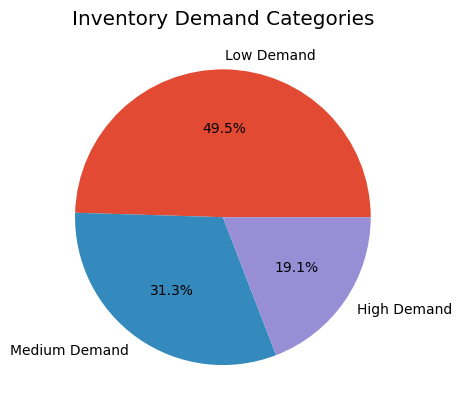

In [8]:
inventory["InventoryStatus"].value_counts().plot(

    kind="pie",

    autopct="%1.1f%%"

)

plt.ylabel("")

plt.title("Inventory Demand Categories")

plt.show()

In [9]:
top_products = inventory.sort_values(

    "TotalRevenue",

    ascending=False

).head(10)

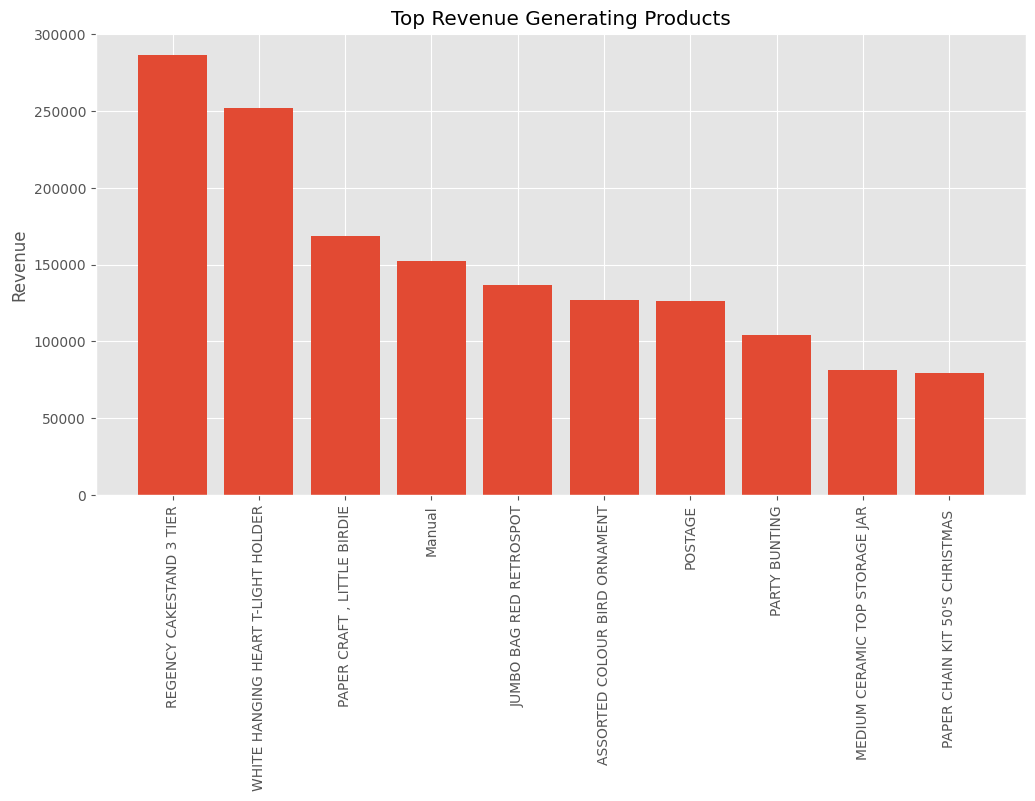

In [10]:
plt.figure(figsize=(12,6))

plt.bar(

    top_products.index,

    top_products["TotalRevenue"]

)

plt.xticks(rotation=90)

plt.title("Top Revenue Generating Products")

plt.ylabel("Revenue")

plt.show()

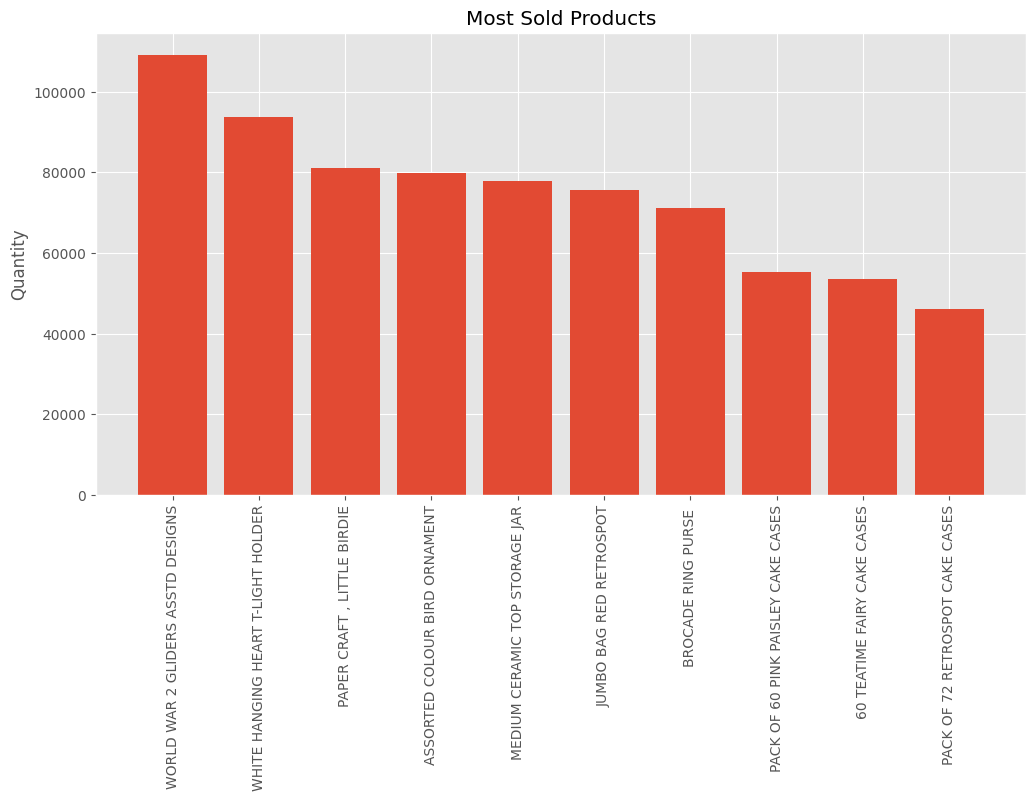

In [11]:
top_quantity = inventory.sort_values(

    "TotalQuantity",

    ascending=False

).head(10)

plt.figure(figsize=(12,6))

plt.bar(

    top_quantity.index,

    top_quantity["TotalQuantity"]

)

plt.xticks(rotation=90)

plt.title("Most Sold Products")

plt.ylabel("Quantity")

plt.show()

In [12]:
inventory.sort_values(

    "ReorderPoint",

    ascending=False

).head(15)

,TotalQuantity,TotalRevenue,TotalOrders,AvgMonthlyDemand,ReorderPoint,InventoryStatus
Description,,,,,,
WORLD WAR 2 GLIDERS ASSTD DESIGNS,109169,24905.87,920,4366.76,6550.14,High Demand
WHITE HANGING HEART T-LIGHT HOLDER,93640,252072.46,4888,3745.60,5618.40,High Demand
"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,1,3239.80,4859.70,High Demand
ASSORTED COLOUR BIRD ORNAMENT,79913,127074.17,2652,3196.52,4794.78,High Demand
MEDIUM CERAMIC TOP STORAGE JAR,77916,81416.73,195,3116.64,4674.96,High Demand
JUMBO BAG RED RETROSPOT,75759,136980.08,2612,3030.36,4545.54,High Demand
BROCADE RING PURSE,71129,14827.71,387,2845.16,4267.74,High Demand
PACK OF 60 PINK PAISLEY CAKE CASES,55270,26733.45,1578,2210.80,3316.20,High Demand
60 TEATIME FAIRY CAKE CASES,53495,26121.57,1765,2139.80,3209.70,High Demand


In [13]:
inventory.to_csv(

    "../data/processed/inventory_analysis.csv"
)

print("Inventory Analysis Saved Successfully!")

Inventory Analysis Saved Successfully!
